# Clustering with quantum annealing

In this notebook, we will describe a mathematical model for the balanced clustering problem and implement an algorithm for solving the clustering problem on the DWave quantum device simulator. We will then compare this solution with the classical approach.

## Mathematical model

***Introduction*** 

The $k$-means clustering method (k-Means) is a popular machine learning algorithm that assigns $N$ data points to $k$ clusters in such a way as to minimize the within-cluster distance. In the balanced version of the algorithm (Balanced k-Means), the size of each cluster is approximately equal to $N/k$.

In this work, we consider a quantum-information formulation of the clustering problem and reduce it to a Binary Quadratic Model (BQM), as well as construct the corresponding QUBO matrix.

***Problem Formulation***

Consider a dataset $X \in \mathbb{R}^{N \times d}$ that must be partitioned into $k$ clusters $\Phi = \{\phi_1, \ldots, \phi_k\}$. Let $\mu_i$ denote the centroid of cluster $\phi_i$. The formal $k$-means objective is given by:
\begin{equation}
\min \sum_{i=1}^{k} \frac{1}{2|\phi_i|} \sum_{x, y \in \phi_i} \|x - y\|^2.
\tag{1}
\end{equation}

Under the assumption that the clusters have equal size, i.e., $|\phi_i| = N/k$, this expression simplifies to:
\begin{equation}
\min \sum_{i=1}^{k} \sum_{x, y \in \phi_i} \|x - y\|^2.
\tag{2}
\end{equation}

Define the distance matrix $D \in \mathbb{R}^{N \times N}$, whose entries are given by:
\begin{equation}
    d_{ij} = \|x_i - x_j\|^2,
\tag{3}
\end{equation}
where $x_i$ and $x_j$ are the $i$-th and $j$-th data points in $X$, respectively.

We also define the binary cluster assignment matrix $\hat{W} \in \mathbb{B}^{N \times k}$, where $\hat{w}_{ij} = 1$ if and only if point $x_i$ belongs to cluster $\phi_j$. Since the clusters are assumed to have equal size, each column of $\hat{W}$ should contain approximately $N/k$ ones. In addition, since each point belongs to exactly one cluster, each row of $\hat{W}$ must contain exactly one entry equal to one.

Using this notation, the inner sum in Eq. (2) can be written as:
\begin{equation}
    \sum_{x,y \in \phi_j} \|x - y\|^2 = \hat{w}'_j{}^T D \hat{w}'_j,
\tag{4}
\end{equation}
where $\hat{w}'_j$ is the $j$-th column of $\hat{W}$. The original problem in Eq. (2) can therefore be represented as a constrained binary optimization problem. To do this, we first reshape the binary matrix $\hat{W}$ into a column vector:
\begin{equation}
    \hat{w} = [\hat{w}_{11}, \dots, \hat{w}_{N1}, \hat{w}_{12}, \dots, \hat{w}_{N2}, \dots, \hat{w}_{1k}, \dots, \hat{w}_{Nk}]^T.
\tag{5}
\end{equation}

Then the minimization problem takes the form:
\begin{equation}
    \min_{\hat{w}} \hat{w}^T (I_k \otimes D) \hat{w},
\tag{6}
\end{equation}
where $I_k$ is the $k \times k$ identity matrix.

***Adding Penalty Functions***

The constraints on $\hat{w}$ can be incorporated by adding penalty terms whose minimization enforces the conditions of the problem.

- **Constraint on balanced cluster sizes**

To enforce the condition that each cluster contains approximately $N/k$ points, we introduce the following penalty:
\begin{equation}
    \alpha (\hat{w}'_j{}^T \hat{w}'_j - N/k)^2,
\tag{7}
\end{equation}
where $\alpha$ is a coefficient chosen large enough to ensure that the constraint is satisfied. Dropping the constant term $\alpha (N/k)^2$, this penalty can be rewritten in matrix form as:
\begin{equation}
    \hat{w}'_j{}^T \alpha F \hat{w}'_j,
\tag{8}
\end{equation}
where $F$ is defined as:
\begin{equation}
    F = \mathbf{1}_N - \frac{2N}{k} I_N,
\tag{9}
\end{equation}
where $\mathbf{1}_N$ is the matrix whose entries are all equal to one. Summing the penalty terms over all $j$, we obtain the total penalty for the cluster-size constraint:
\begin{equation}
    \hat{w}^T (I_k \otimes \alpha F) \hat{w}.
\tag{10}
\end{equation}

- **Constraint that each point belongs to exactly one cluster**

To enforce the condition that each point must belong to exactly one cluster, we add the penalty:
\begin{equation}
    \beta (\hat{w}_i^T \hat{w}_i - 1)^2,
\tag{11}
\end{equation}
where $\beta$ is an analogous penalty coefficient, and $\hat{w}_i$ is the $i$-th row of the matrix $\hat{W}$. Omitting the constant term, we obtain:
\begin{equation}
    \hat{w}_i^T \beta G \hat{w}_i,
\tag{12}
\end{equation}
where $G$ is defined as:
\begin{equation}
    G = \mathbf{1}_k - 2I_k.
\tag{13}
\end{equation}

To obtain the sum of all row-wise penalties, we first represent $\hat{w}$ in an alternative form $\hat{v}$:
\begin{equation}
    \hat{v} = [\hat{w}_{11}, \dots, \hat{w}_{1k}, \hat{w}_{21}, \dots, \hat{w}_{2k}, \dots, \hat{w}_{N1}, \dots, \hat{w}_{Nk}]^T.
\tag{14}
\end{equation}

This permutation of elements is achieved through a linear transformation using a matrix $Q \in \mathbb{B}^{Nk \times Nk}$, whose entries are defined as:
\begin{equation}
    q_{ij} = \begin{cases}
    1, & \text{if } j = N\operatorname{mod}(i-1, k) + \left\lfloor \frac{i-1}{k} \right\rfloor + 1, \\
    0, & \text{otherwise}.
    \end{cases}
\tag{15}
\end{equation}

After applying $Q$, the row-wise penalty takes the form:
\begin{equation}
    \hat{v}^T (I_N \otimes \beta G) \hat{v}.
\tag{16}
\end{equation}

Using $\hat{w} = Q^T \hat{v}$, we rewrite this penalty in terms of $\hat{w}$:
\begin{equation}
    \hat{w}^T Q^T (I_N \otimes \beta G) Q \hat{w}.
\tag{17}
\end{equation}

***Final QUBO Formulation***

Combining the main objective function and the penalty terms, we arrive at the final QUBO formulation:
\begin{equation}
    \min  \hat{w}^T \left( I_k \otimes (D + \alpha F) + Q^T (I_N \otimes \beta G) Q \right) \hat{w}.
\tag{18}
\end{equation}

This expression is identical to the canonical QUBO form:
\begin{equation}
    \min z^T A z + b^T z,
\tag{19}
\end{equation}
where:
\begin{equation}
    z = \hat{w}, \quad A = I_k \otimes (D + \alpha F) + Q^T (I_N \otimes \beta G) Q, \quad b = 0.
\tag{20}
\end{equation}

Thus, problem (2) has been transformed into a QUBO problem, which can be solved using an adiabatic quantum computer.

## Solving the Problem Using a Quantum Annealing Emulator

Let us consider a specific clustering problem. We begin by generating synthetic data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

Defining parameters

In [2]:
N = 50 # number of datapoints
d = 2  # dimensionality of data
k = 3  # number of clusters

In [3]:
# === Generation of cluster centers ===
centers = np.random.uniform(0, 10, size=(k, d))

# === Distribution of points into clusters (accounting for N%k) ===
base = N // k
rem = N % k
counts = [base + (1 if i < rem else 0) for i in range(k)]

# === Generation of data and true labels ===
X = np.vstack([np.random.randn(counts[i], d) + centers[i] for i in range(k)])
labels_true = np.concatenate([[i] * counts[i] for i in range(k)])
print(f"Generated data: N={N}, d={d}, k={k}")

Generated data: N=50, d=2, k=3


Let us visualize the resulting data (for convenience, we use $d = 2$).

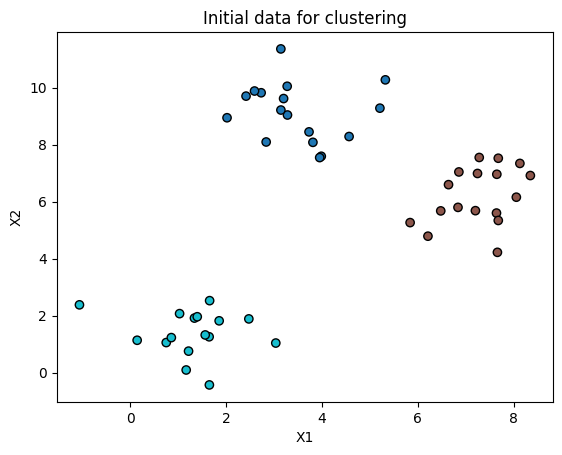

In [4]:
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=labels_true, cmap='tab10', edgecolor='k')
plt.title("Initial data for clustering")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

Let us define the pairwise distance matrix.

In [5]:
D = np.array([[np.linalg.norm(x_i - x_j)**2 for x_j in X] for x_i in X])
D.shape

(50, 50)

Let us construct the QUBO matrix.

In [6]:
import dimod
from neal import SimulatedAnnealingSampler

In [7]:
alpha = np.max(D) / (2 * N / k - 1) # balanced cluster size
beta = np.max(D) # unique point assignment

F = np.ones((N, N)) - (2*N/k) * np.eye(N)
G = np.ones((k, k)) - 2 * np.eye(k)

Q = np.zeros((N*k, N*k))
for i in range(N*k):
    r = i % k           # r = (i-1 mod k) with the offset of 1
    f = i // k          # f = floor((i-1)/k)
    j = N * r + f       # j = N*r + f  (0-based)
    Q[i, j] = 1


In [ ]:
# Final QUBO matrix
A = np.kron(np.eye(k), D + alpha * F) + Q.T @ np.kron(np.eye(N), beta * G) @ Q

Constructing the BQM

In [10]:
bqm = dimod.BinaryQuadraticModel({}, {}, 0.0, dimod.BINARY)

for i in range(N*k):
    bqm.add_variable(i, A[i, i])
    
# quadratic terms
for i in range(N*k):
    for j in range(i+1, N*k):
        if A[i, j] != 0:
            bqm.add_interaction(i, j, A[i, j])

In [11]:
sampler = SimulatedAnnealingSampler()
sampleset = sampler.sample(bqm, num_reads=1000)
best = sampleset.first.sample

In [12]:
labels = np.zeros(N, dtype=int)
for u, val in best.items():
    if val:
        labels[u % N] = u // N
print("Cluster labels:", labels)

Cluster labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [13]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(labels_true, labels)
nmi = normalized_mutual_info_score(labels_true, labels)

print(f"Adjusted Rand Index: {ari:.2f}")
print(f"Normalized Mutual Information: {nmi:.2f}")

Adjusted Rand Index: 1.00
Normalized Mutual Information: 1.00


Judging by the clustering quality metrics, the obtained result is very strong. Let us visualize it.

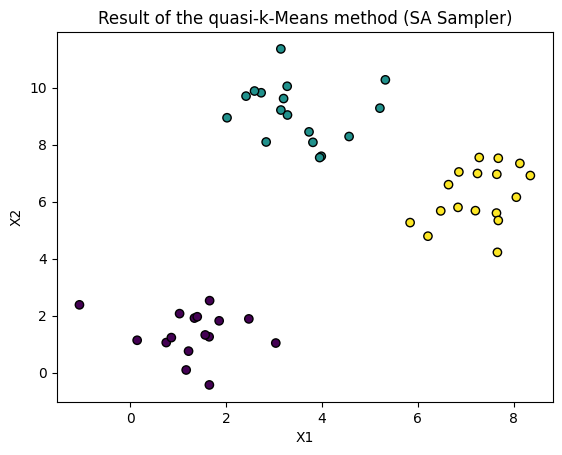

In [14]:
labels = np.zeros(N, dtype=int)
for var, val in best.items():
    if val:
        labels[var % N] = var // N

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolor='k')
plt.title("Result of the quasi-k-Means method (SA Sampler)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()


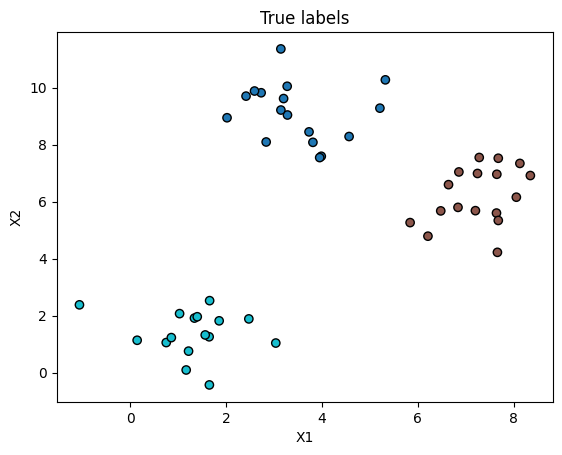

In [15]:
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=labels_true, cmap='tab10', edgecolor='k')
plt.title("True labels")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

Excellent — only one point was misclassified. Let us now examine how our model performs on the Wine dataset (https://archive.ics.uci.edu/dataset/109/wine)

In [16]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.decomposition import PCA

In [17]:
data = load_wine()

X = data.data
X = StandardScaler().fit_transform(X)
y = data.target

unique, counts = np.unique(y, return_counts=True)
min_count = np.min(counts)

X_bal_list, y_bal_list = [], []
for cls in unique:
    X_cls = X[y == cls]
    y_cls = y[y == cls]
    X_res, y_res = resample(X_cls, y_cls, replace=False, n_samples=min_count, random_state=42)
    X_bal_list.append(X_res)
    y_bal_list.append(y_res)

X_bal = np.vstack(X_bal_list)
y_bal = np.hstack(y_bal_list)

N, d = X_bal.shape
k = len(set(y_bal))



In [18]:
D = np.sum((X_bal[:, None, :] - X_bal[None, :, :])**2, axis=2)

alpha = np.max(D) / (2 * N / k - 1) # balanced cluster size
beta = np.max(D) # unique point assignment

F = np.ones((N, N)) - (2*N/k)*np.eye(N)
G = np.ones((k, k)) - 2*np.eye(k)

Nk = N * k
Q = np.zeros((Nk, Nk), dtype=int)
for i in range(Nk):
    r = i % k
    f = i // k
    j = N*r + f
    Q[i, j] = 1


In [ ]:
A = np.kron(np.eye(k), D + alpha*F) + Q.T @ np.kron(np.eye(N), beta*G) @ Q

# Forming the BQM
bqm = dimod.BinaryQuadraticModel({}, {}, 0.0, dimod.BINARY)
for i in range(Nk):
    bqm.add_variable(i, A[i, i])
for i in range(Nk):
    for j in range(i+1, Nk):
        if abs(A[i, j]) > 1e-8:
            bqm.add_interaction(i, j, A[i, j])

In [21]:
sampler = SimulatedAnnealingSampler()
sampleset = sampler.sample(bqm, num_reads=1000)
best = sampleset.first.sample

In [22]:
labels = np.zeros(N, dtype=int)
for var, val in best.items():
    if val == 1:
        labels[var % N] = var // N

In [23]:
ari = adjusted_rand_score(y_bal, labels)
nmi = normalized_mutual_info_score(y_bal, labels)
print(f"Adjusted Rand Index:            {ari:.3f}")
print(f"Normalized Mutual Information:   {nmi:.3f}")

Adjusted Rand Index:            0.187
Normalized Mutual Information:   0.390


In [ ]:
# Visualization in PCA-space
pca = PCA(n_components=2)
X2 = pca.fit_transform(X_bal)


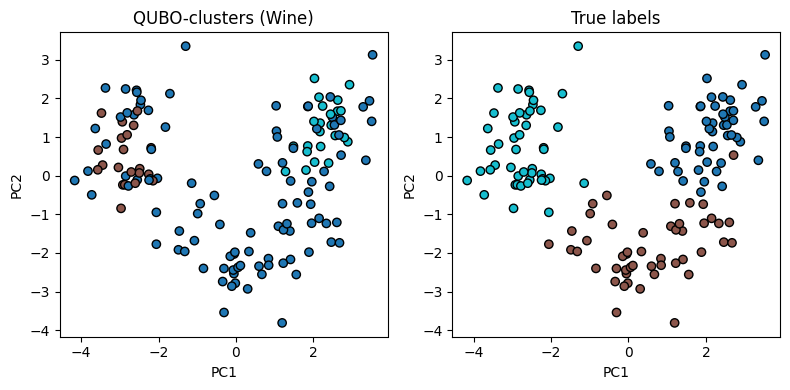

In [25]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.scatter(X2[:,0], X2[:,1], c=labels, cmap='tab10', edgecolor='k')
plt.title("QUBO-clusters (Wine)")
plt.xlabel("PC1"); plt.ylabel("PC2")

plt.subplot(1,2,2)
plt.scatter(X2[:,0], X2[:,1], c=y_bal, cmap='tab10', edgecolor='k')
plt.title("True labels")
plt.xlabel("PC1"); plt.ylabel("PC2")

plt.tight_layout()
plt.show()